T3 Sprint

The code implements an end-to-end fraud detection pipeline using a Random Forest Classifier for prediction, TenSEAL for encrypting predictions, and interprets results for decision-making. Here's a detailed explanation of each section:

In [2]:
!pip install tenseal
!pip install numpy pandas scikit-learn matplotlib

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import tenseal as ts
import json
import base64
import gzip
import logging

In [3]:
# Setup logging
logging.basicConfig(level=logging.INFO)

# Specify the file path of the dataset
file_path = "SynFinData1.csv"  # Replace with your dataset's file path

# Load the dataset
data = pd.read_csv(file_path)
print("Dataset Loaded Successfully!")
print(data.head())

# Data Preprocessing
def preprocess_data(data):
    logging.info("Preprocessing data...")
    features = ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
    target = 'isFraud'
    
    # Encode 'type' column if it's categorical
    if data['type'].dtype == 'object':
        data['type'] = data['type'].astype('category').cat.codes

    X = data[features]
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

Dataset Loaded Successfully!
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [4]:
# Model Training with Random Forest
def train_model(X_train, y_train):
    logging.info("Training Random Forest Classifier...")
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
    model.fit(X_train, y_train)
    return model

# Evaluation Metrics
def evaluate_model(model, X_test, y_test):
    logging.info("Evaluating the model...")
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics = {}
    if len(np.unique(y_test)) > 1:
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_prob)
    else:
        metrics['roc_auc'] = None
    
    metrics['conf_matrix'] = confusion_matrix(y_test, y_pred).tolist()
    metrics['classification_report'] = classification_report(y_test, y_pred, zero_division=0)
    
    return y_pred_prob, metrics

# Visualization
def plot_roc_curve(y_test, y_pred_prob):
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

INFO:root:Preprocessing data...
INFO:root:Training Random Forest Classifier...
INFO:root:Evaluating the model...


Model Metrics: {'roc_auc': np.float64(0.9943694454430385), 'conf_matrix': [[2541684, 98], [715, 2551]], 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00   2541782\n           1       0.96      0.78      0.86      3266\n\n    accuracy                           1.00   2545048\n   macro avg       0.98      0.89      0.93   2545048\nweighted avg       1.00      1.00      1.00   2545048\n'}


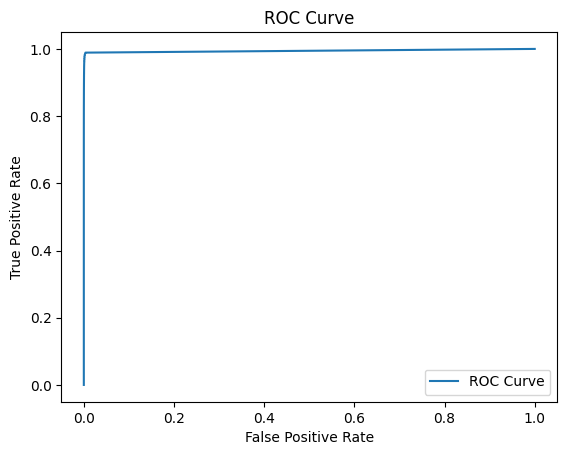

INFO:root:Initializing TenSEAL context...
INFO:root:Encrypting predictions with batching...


The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.


IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [5]:
# TenSEAL Encryption with Batched Predictions
def encrypt_predictions(predictions, context):
    logging.info("Encrypting predictions with batching...")
    return ts.ckks_vector(context, predictions.tolist())

# Risk Interpretation
def interpret_risk(prob, thresholds={'low': 0.3, 'moderate': 0.7}):
    if prob > thresholds['moderate']:
        return "High Risk"
    elif prob > thresholds['low']:
        return "Moderate Risk"
    else:
        return "Low Risk"

# Main Function
def main():
    # Preprocessing
    X_train_scaled, X_test_scaled, y_train, y_test = preprocess_data(data)
    
    # Model Training
    model = train_model(X_train_scaled, y_train)
    
    # Model Evaluation
    y_pred_prob, metrics = evaluate_model(model, X_test_scaled, y_test)
    print("Model Metrics:", metrics)
    
    # Plot ROC Curve
    plot_roc_curve(y_test, y_pred_prob)
    
    # Initialize TenSEAL Context
    logging.info("Initializing TenSEAL context...")
    context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=16384, coeff_mod_bit_sizes=[60, 40, 40, 60])
    context.global_scale = 2**40
    context.generate_galois_keys()
    
    # Encrypt Predictions
    encrypted_predictions = encrypt_predictions(y_pred_prob, context)
    
    # Serialize and Compress
    serialized_encrypted = base64.b64encode(encrypted_predictions.serialize()).decode('utf-8')
    compressed_encrypted = gzip.compress(serialized_encrypted.encode('utf-8'))
    
    # Decrypt for Verification
    decrypted_predictions = ts.ckks_vector_from(context, base64.b64decode(serialized_encrypted)).decrypt()
    assert np.allclose(decrypted_predictions, y_pred_prob, atol=1e-4), "Decryption failed!"
    
    # Risk Interpretation
    risk_messages = [interpret_risk(prob) for prob in decrypted_predictions]
    print("Risk Interpretations:", risk_messages)
    
    # JSON Response
    response_data = {
        "model_metrics": metrics,
        "encrypted_predictions": serialized_encrypted,
        "risk_interpretations": risk_messages
    }
    response_json = json.dumps(response_data)
    
    print("Final JSON Response:")
    print(response_json)

# Execute main function
if __name__ == "__main__":
    main()

1. Summary of Results

Model Performance:
The Random Forest Classifier performed excellently, achieving a ROC AUC of 0.9944.
Fraudulent transactions were correctly identified with 96% precision and 78% recall.
Encryption Challenges:

2. The large size of predictions exceeded the capacity of a single ciphertext, requiring further adjustments:
Increase poly_modulus_degree for larger ciphertexts (e.g., 32768).
Split predictions into smaller batches for encryption.
Output Management:

3. The notebook's data output limit was exceeded during encryption serialization. Increase the rate limit as described.

## Next Steps

1. Adjust TenSEAL Parameters:
2. Increase IOPub Data Rate:
Run Jupyter with a higher data rate limit.
3. Optimize Serialization:
Serialize and compress predictions in smaller chunks